In [2]:
!pip install --upgrade torch_geometric

!pip install torch-scatter torch-sparse torch-cluster pyg-lib -f https://data.pyg.org/whl/torch-$(python -c 'import torch; print(torch.__version__)').html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.8 MB/s eta 0:00:0000:01
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 99.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 66.9 MB/s eta 0:00:00:00:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 85.2 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 98.9 MB/s eta 0:00:00:00:01


CT-GNN

Step 1: Loading Data...
Step 4: Training CT-GNN...
Epoch 010 | Train Loss: 0.0062 | Val F1: 0.6343
Epoch 020 | Train Loss: 0.0072 | Val F1: 0.6880
Epoch 030 | Train Loss: 0.0065 | Val F1: 0.5821
Early stopping!

Step 5: Final Evaluation...

--- CT-GNN RESULTS ---
              precision    recall  f1-score   support

       Licit       0.97      1.00      0.98      8433
     Illicit       0.91      0.36      0.51       408

    accuracy                           0.97      8841
   macro avg       0.94      0.68      0.75      8841
weighted avg       0.97      0.97      0.96      8841

ROC AUC: 0.8460
Vẽ biểu đồ tổng hợp cho CT-GNN...
saved: 'ct-gnn_full_report.png'


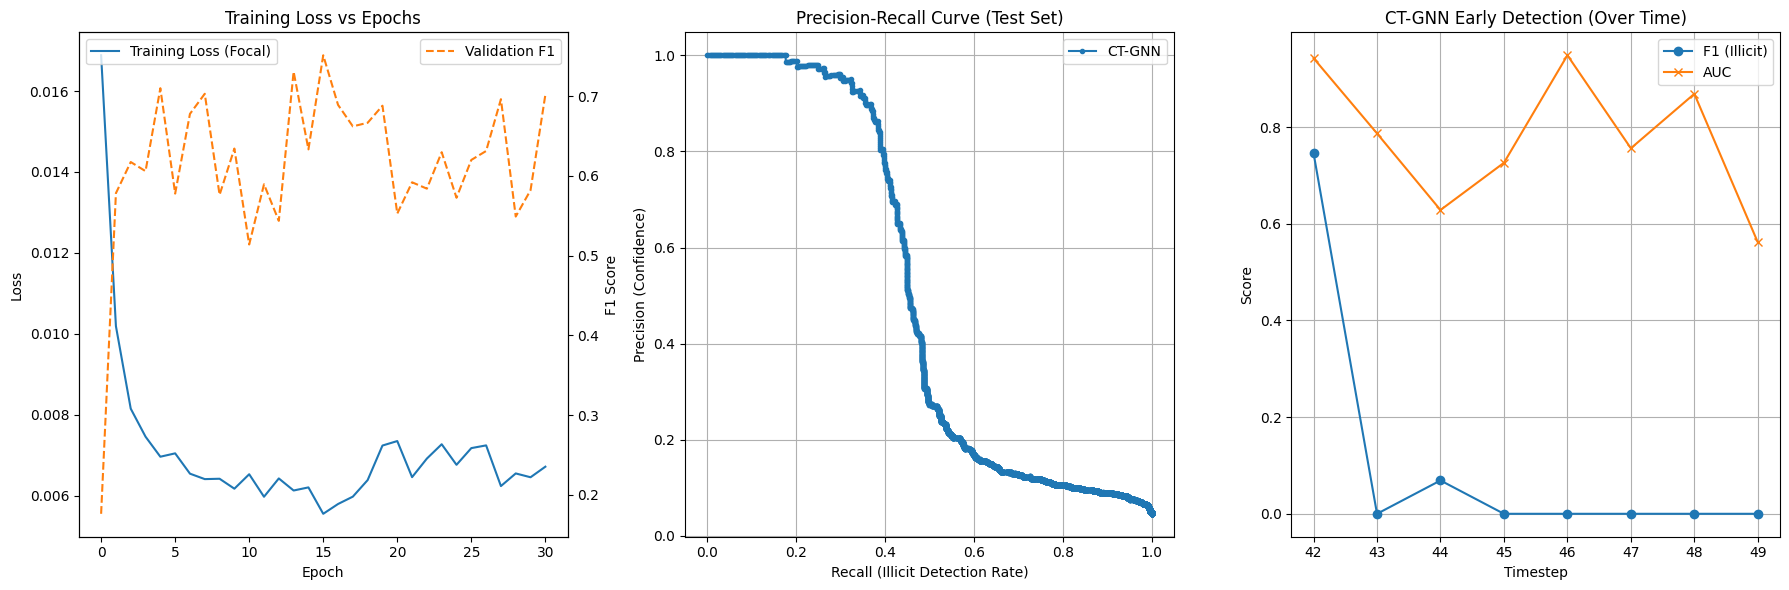

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_recall_curve, precision_score, recall_score
import matplotlib.pyplot as plt
import math

# --- 1. Load Data ---
print("Step 1: Loading Data...")
try:
    df_features = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_features.csv', header=None)
    df_classes = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_classes.csv')
    df_edgelist = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_edgelist.csv')
except FileNotFoundError:
    print("Error: CSV files not found.")
    exit()

feature_cols = ['txId', 'timestep'] + [f'local_{i}' for i in range(93)] + [f'agg_{i}' for i in range(72)]
df_features.columns = feature_cols
all_tx_ids = df_features['txId'].unique()
tx_id_map = {tx_id: i for i, tx_id in enumerate(all_tx_ids)}
df_edgelist['txId1_idx'] = df_edgelist['txId1'].map(tx_id_map)
df_edgelist['txId2_idx'] = df_edgelist['txId2'].map(tx_id_map)
df_merged = pd.merge(df_features, df_classes, on='txId', how='left')
df_merged['class'] = df_merged['class'].map({'2': 0, '1': 1, 'unknown': np.nan})
df_merged = df_merged.set_index('txId').loc[all_tx_ids].reset_index()

features_no_time = [col for col in df_features.columns if col not in ['txId', 'timestep']]
X_df = df_merged[features_no_time]
y_series = df_merged['class']
timesteps = df_merged['timestep'].values

# Train/Val/Test Split
train_mask_idx = X_df.index[(timesteps <= 34) & (y_series.notna())].values
val_mask_idx = X_df.index[(timesteps >= 35) & (timesteps <= 41) & (y_series.notna())].values
test_mask_idx = X_df.index[(timesteps >= 42) & (timesteps <= 49) & (y_series.notna())].values

scaler = StandardScaler()
X_train_features = X_df.loc[train_mask_idx]
scaler.fit(X_train_features)
X_scaled = scaler.transform(X_df)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data = Data(
    x=torch.tensor(X_scaled, dtype=torch.float),
    edge_index=torch.tensor(df_edgelist[['txId1_idx', 'txId2_idx']].values.T, dtype=torch.long),
    y=torch.tensor(y_series.values, dtype=torch.long),
    ts=torch.tensor(timesteps, dtype=torch.float) 
)
data.train_mask = torch.tensor(train_mask_idx, dtype=torch.long)
data.val_mask = torch.tensor(val_mask_idx, dtype=torch.long)
data.test_mask = torch.tensor(test_mask_idx, dtype=torch.long)

# Loader Neighbor Sampling
train_loader = NeighborLoader(data, num_neighbors=[10, 10], batch_size=1024, input_nodes=data.train_mask, shuffle=True)
val_loader = NeighborLoader(data, num_neighbors=[10, 10], batch_size=1024, input_nodes=data.val_mask)
test_loader = NeighborLoader(data, num_neighbors=[10, 10], batch_size=1024, input_nodes=data.test_mask)

# --- 2. Focal Loss ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        return torch.mean(F_loss)

# --- 3. CT-GNN Model (With increased Dropout) ---
class TimeEncoder(nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        self.w = nn.Linear(1, out_channels // 2) 
        self.p = nn.Linear(1, out_channels // 2)
    def forward(self, t):
        t = t.unsqueeze(-1)
        return torch.cat([torch.cos(self.w(t) + self.p(t)), torch.sin(self.w(t) + self.p(t))], dim=-1)

class CTGNNLayer(MessagePassing):
    def __init__(self, in_channels, out_channels, time_channels, heads=2, dropout=0.2):
        super().__init__(node_dim=0, aggr='add')
        self.heads = heads
        self.head_dim = out_channels // heads
        self.dropout = dropout
        
        total_in_dim = in_channels + time_channels
        self.lin_q = nn.Linear(total_in_dim, out_channels)
        self.lin_k = nn.Linear(total_in_dim, out_channels)
        self.lin_v = nn.Linear(total_in_dim, out_channels)
        self.lin_skip = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, t_emb):
        x_in = torch.cat([x, t_emb], dim=-1)
        q = self.lin_q(x_in).view(-1, self.heads, self.head_dim)
        k = self.lin_k(x_in).view(-1, self.heads, self.head_dim)
        v = self.lin_v(x_in).view(-1, self.heads, self.head_dim)

        out = self.propagate(edge_index, q=q, k=k, v=v, size=None)
        out = out.view(-1, self.heads * self.head_dim)
        out = out + self.lin_skip(x)
        return out

    def message(self, q_i, k_j, v_j, index, ptr, size_i):
        alpha = (q_i * k_j).sum(dim=-1) / np.sqrt(self.head_dim)
        alpha = softmax(alpha, index, ptr, size_i)
        
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        return v_j * alpha.unsqueeze(-1)

class CTGNNModel(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes, time_dim=32):
        super().__init__()
        self.time_enc = TimeEncoder(time_dim)
        self.conv1 = CTGNNLayer(num_features, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.conv2 = CTGNNLayer(hidden_dim, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.lin_out = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(p=0.4) 

    def forward(self, x, edge_index, t):
        t_emb = self.time_enc(t)
        x = F.relu(self.conv1(x, edge_index, t_emb))
        x = self.dropout(x) # Apply dropout
        x = F.relu(self.conv2(x, edge_index, t_emb))
        x = self.dropout(x) # Apply dropout
        out = self.lin_out(x)
        return F.log_softmax(out, dim=1)

# --- 4. Training Setup ---
print("Step 4: Training CT-GNN...")
model = CTGNNModel(
    num_features=165, 
    hidden_dim=128, 
    num_classes=2,
    time_dim=64
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4) 
loss_fn = FocalLoss(alpha=0.25, gamma=2.0) # Use Focal Loss instead of CrossEntropy

# Training Loop
train_losses, val_losses = [], []
best_val_f1 = 0 
patience = 15   

for epoch in range(100): 
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Time Jittering (Data Augmentation)
        noise = (torch.rand_like(batch.ts) - 0.5) * 0.1 
        t_noisy = batch.ts + noise
        
        out = model(batch.x, batch.edge_index, t_noisy)
        loss = loss_fn(out[:batch.batch_size], batch.y[:batch.batch_size])
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    all_val_true, all_val_pred = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.ts)
            pred = out[:batch.batch_size].argmax(dim=1)
            
            all_val_true.extend(batch.y[:batch.batch_size].cpu().numpy())
            all_val_pred.extend(pred.cpu().numpy())
            
    val_f1 = f1_score(all_val_true, all_val_pred, pos_label=1, zero_division=0)
    val_losses.append(val_f1) 

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_ct-gnn.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping!")
            break

# --- 5. Final Evaluation ---
print("\nStep 5: Final Evaluation...")
model.load_state_dict(torch.load('best_ct-gnn.pth'))
model.eval()

all_true, all_pred, all_proba, all_ts = [], [], [], []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.ts)
        
        target_out = out[:batch.batch_size]
        target_ts = batch.ts[:batch.batch_size].cpu().numpy()
        
        all_true.append(batch.y[:batch.batch_size].cpu().numpy())
        all_pred.append(target_out.argmax(dim=1).cpu().numpy())
        all_proba.append(target_out.exp()[:, 1].cpu().numpy())
        all_ts.append(target_ts)

y_true = np.concatenate(all_true)
y_pred = np.concatenate(all_pred)
y_proba = np.concatenate(all_proba)
timesteps_test = np.concatenate(all_ts)

print("\n--- CT-GNN RESULTS ---")
print(classification_report(y_true, y_pred, target_names=['Licit', 'Illicit']))
print(f"ROC AUC: {roc_auc_score(y_true, y_proba):.4f}")

# Visualize Early Detection
unique_ts = sorted(np.unique(timesteps_test))
f1_time, auc_time = [], []

for t in unique_ts:
    mask = (timesteps_test == t)
    if np.sum(mask) > 0 and len(np.unique(y_true[mask])) > 1:
        f1_time.append(f1_score(y_true[mask], y_pred[mask], pos_label=1, zero_division=0))
        auc_time.append(roc_auc_score(y_true[mask], y_proba[mask]))
    else:
        f1_time.append(0.0)
        auc_time.append(0.5)

#plt.figure(figsize=(12, 5))
#plt.plot(unique_ts, f1_time, marker='o', label='F1 (Illicit)')
#plt.plot(unique_ts, auc_time, marker='x', label='AUC')
#plt.title('CT-GNN Early Detection')
#plt.xlabel('Timestep')
#plt.ylabel('Score')
#plt.legend()
#plt.grid(True)
#plt.savefig('ct-gnn_results.png')
#print("Saved result plot.")
# --- Step 6: Full Visualization ---
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

print("Vẽ biểu đồ tổng hợp cho CT-GNN...")

plt.figure(figsize=(18, 6))

# 1. Loss and Validation F1
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Training Loss (Focal)', color='tab:blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Epochs')
plt.legend(loc='upper left')

ax2 = plt.gca().twinx()
ax2.plot(val_losses, label='Validation F1', color='tab:orange', linestyle='--')
ax2.set_ylabel('F1 Score')
ax2.legend(loc='upper right')
#plt.title('Training Loss & Validation F1')

# 2. Precision-Recall
plt.subplot(1, 3, 2)
precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_proba, pos_label=1)
plt.plot(recall_curve, precision_curve, marker='.', label='CT-GNN')
plt.title('Precision-Recall Curve (Test Set)')
plt.xlabel('Recall (Illicit Detection Rate)')
plt.ylabel('Precision (Confidence)')
plt.grid(True)
plt.legend()

# 3. Early Detection
plt.subplot(1, 3, 3)
plt.plot(unique_ts, f1_time, marker='o', label='F1 (Illicit)')
plt.plot(unique_ts, auc_time, marker='x', label='AUC')
plt.title('CT-GNN Early Detection (Over Time)')
plt.xlabel('Timestep')
plt.ylabel('Score')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('ct-gnn_full_report.png')
print("saved: 'ct-gnn_full_report.png'")
plt.show()